## Benchmark Maps And Comparative Plot
Load a benchmark CSV, compare methods, and visualize init vs best routes for each method.

Using benchmark CSV: benchmark_R201_20260407_180142.csv


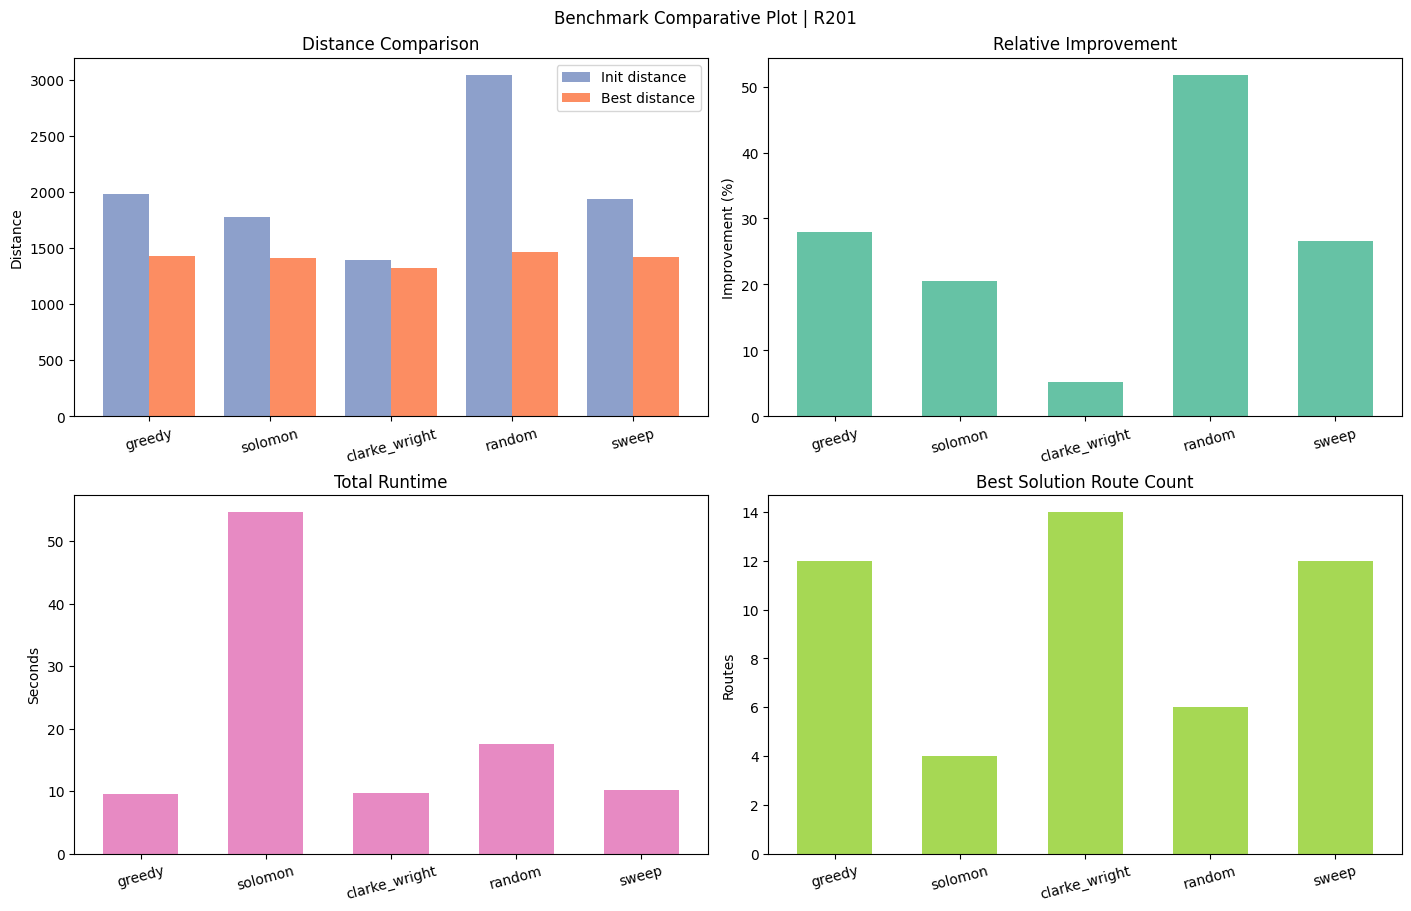

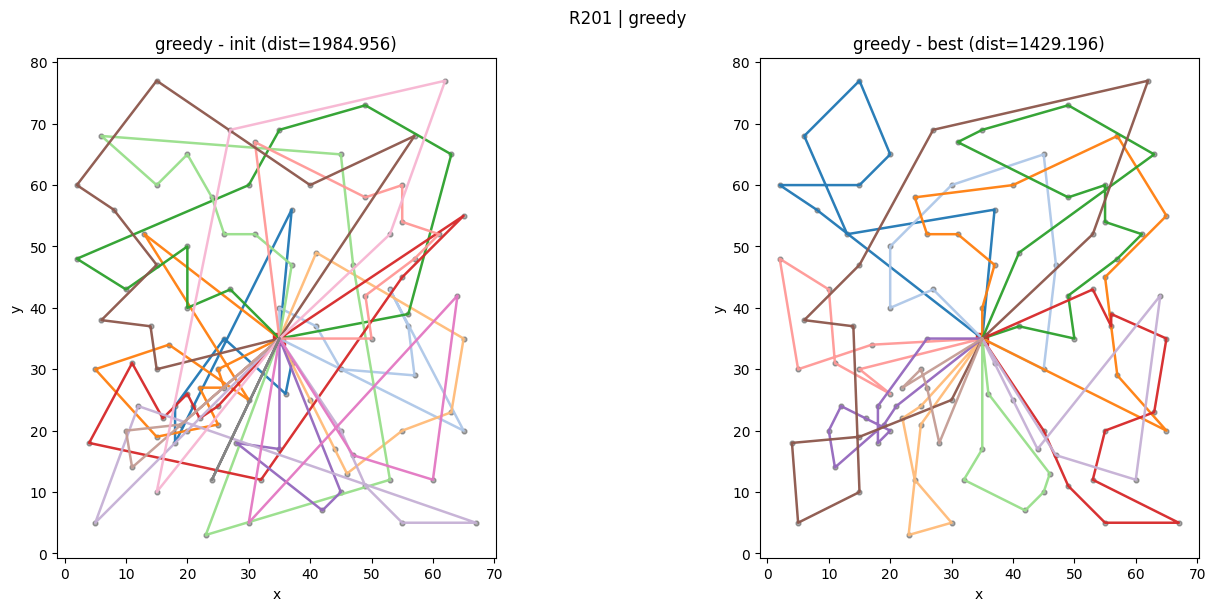

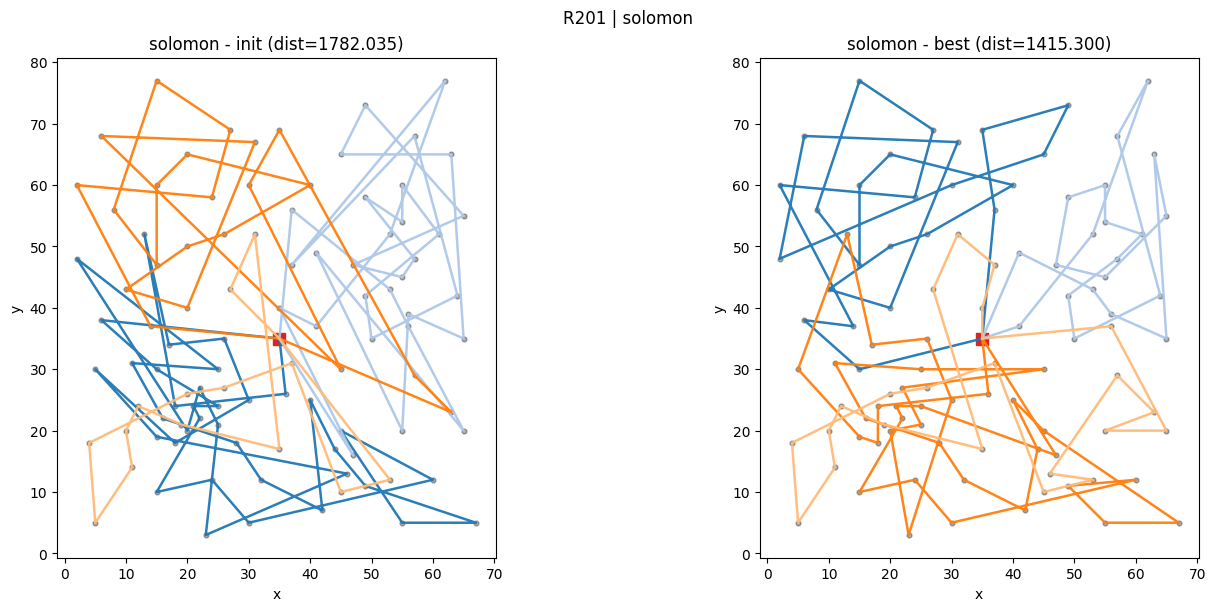

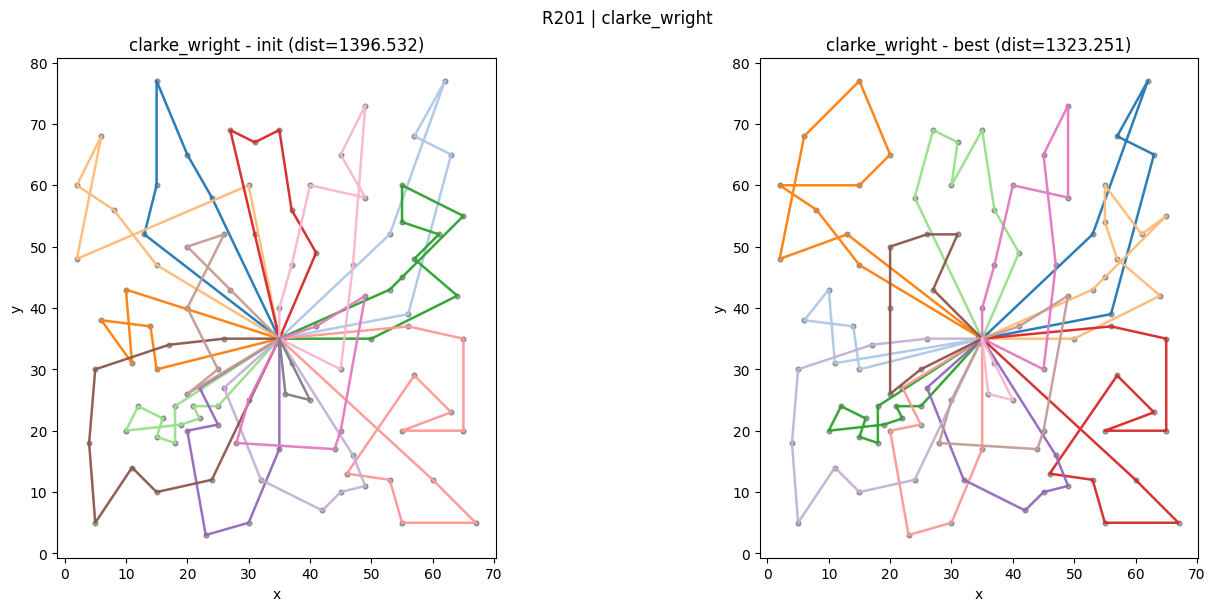

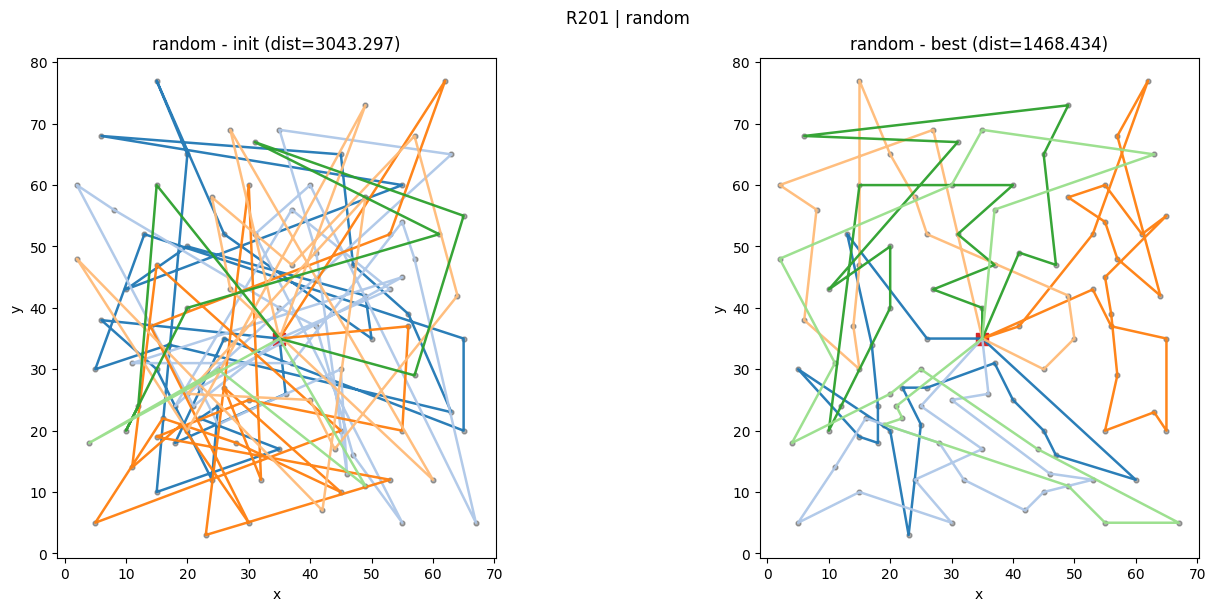

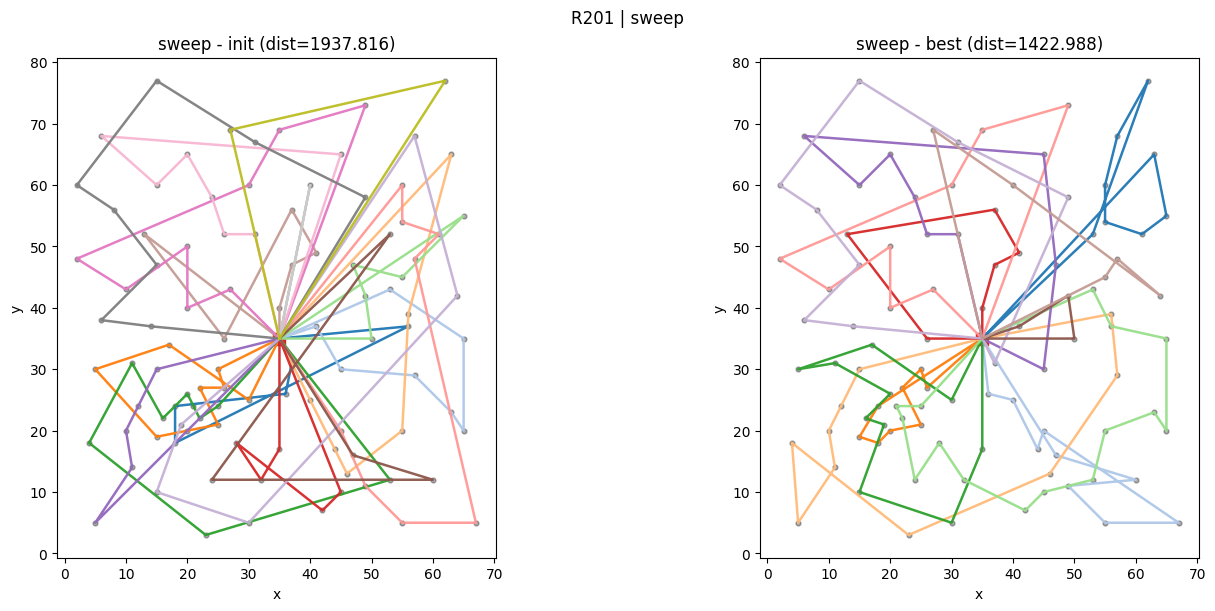

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from utils.parser import parse_instance

# Pick latest benchmark CSV automatically.
benchmark_files = sorted((SRC / "results").glob("benchmark_*.csv"), key=lambda p: p.stat().st_mtime)
assert benchmark_files, "No benchmark CSV found in src/results"
benchmark_csv = benchmark_files[-1]
# Optional: pick a specific benchmark file manually (uncomment and edit filename).
# benchmark_csv = SRC / "results" / "benchmark_C201_20260407_174323.csv"
# assert benchmark_csv.exists(), f"Benchmark file not found: {benchmark_csv}"
print(f"Using benchmark CSV: {benchmark_csv.name}")

df = pd.read_csv(benchmark_csv)
df = df[df["benchmark_stage"] == "tabu"].copy()
assert not df.empty, "No 'tabu' rows found in benchmark CSV"

instance = df.iloc[0]["instance"]
problem = parse_instance(instance)

# Comparative plot (distance/time/routes)
methods = df["method"].tolist()
init_distance = df["init_distance"].astype(float).to_numpy()
best_distance = df["tabu_distance"].astype(float).to_numpy()
total_time = df["total_elapsed_seconds"].astype(float).to_numpy()
best_routes = df["routes_used"].astype(float).to_numpy()
improvement_pct = np.where(init_distance > 0, (init_distance - best_distance) / init_distance * 100.0, 0.0)

x = np.arange(len(methods))
bar_w = 0.38
fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

ax = axes[0, 0]
ax.bar(x - bar_w / 2, init_distance, width=bar_w, label="Init distance", color="#8da0cb")
ax.bar(x + bar_w / 2, best_distance, width=bar_w, label="Best distance", color="#fc8d62")
ax.set_title("Distance Comparison")
ax.set_ylabel("Distance")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15)
ax.legend()

ax = axes[0, 1]
ax.bar(x, improvement_pct, width=0.6, color="#66c2a5")
ax.set_title("Relative Improvement")
ax.set_ylabel("Improvement (%)")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15)

ax = axes[1, 0]
ax.bar(x, total_time, width=0.6, color="#e78ac3")
ax.set_title("Total Runtime")
ax.set_ylabel("Seconds")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15)

ax = axes[1, 1]
ax.bar(x, best_routes, width=0.6, color="#a6d854")
ax.set_title("Best Solution Route Count")
ax.set_ylabel("Routes")
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=15)

fig.suptitle(f"Benchmark Comparative Plot | {instance}")
plt.show()


def plot_solution(ax, routes, title):
    depot = problem.customers[problem.depot_id]
    xs = [problem.customers[cid].x for cid in problem.customer_ids]
    ys = [problem.customers[cid].y for cid in problem.customer_ids]

    ax.scatter(xs, ys, s=12, c="#444444", alpha=0.45)
    ax.scatter([depot.x], [depot.y], s=70, c="#d62728", marker="s")

    cmap = plt.get_cmap("tab20")
    for i, route in enumerate(routes):
        route_x = [problem.customers[node].x for node in route]
        route_y = [problem.customers[node].y for node in route]
        ax.plot(route_x, route_y, color=cmap(i % 20), linewidth=1.8, alpha=0.95)

    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("x")
    ax.set_ylabel("y")


# Per-method map: init vs best
for _, row in df.iterrows():
    method = row["method"]
    init_routes = json.loads(row["init_solution"])
    best_routes_data = json.loads(row["best_solution"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
    plot_solution(axes[0], init_routes, f"{method} - init (dist={float(row['init_distance']):.3f})")
    plot_solution(axes[1], best_routes_data, f"{method} - best (dist={float(row['tabu_distance']):.3f})")
    fig.suptitle(f"{instance} | {method}")
    plt.show()